# 01 — Data Exploration: HHAR & PAMAP2

Explores both datasets used in the GNN+LSTM HAR project.
All results load from pre-processed `.npy` files in `data/processed/`.

Goals:
1. Inspect dataset structure, shapes, and class distributions
2. Visualise raw sensor signals per activity
3. Check per-subject window counts and class balance


In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set_theme(style='whitegrid')

PROCESSED = Path('../data/processed')
PLOTS     = Path('../results/plots')

# Load processed arrays
hhar_X    = np.load(PROCESSED / 'hhar_X.npy')
hhar_y    = np.load(PROCESSED / 'hhar_y.npy')
hhar_subj = np.load(PROCESSED / 'hhar_subjects.npy')
p2_X      = np.load(PROCESSED / 'pamap2_X.npy')
p2_y      = np.load(PROCESSED / 'pamap2_y.npy')
p2_subj   = np.load(PROCESSED / 'pamap2_subjects.npy')

print(f"HHAR   — windows: {len(hhar_X):,}  shape: {hhar_X.shape}  classes: {len(np.unique(hhar_y))}  subjects: {len(np.unique(hhar_subj))}")
print(f"PAMAP2 — windows: {len(p2_X):,}  shape: {p2_X.shape}  classes: {len(np.unique(p2_y))}  subjects: {len(np.unique(p2_subj))}")


HHAR   — windows: 454,577  shape: (454577, 128, 3)  classes: 6  subjects: 9
PAMAP2 — windows: 15,049  shape: (15049, 128, 18)  classes: 12  subjects: 9


## 1. HHAR Dataset

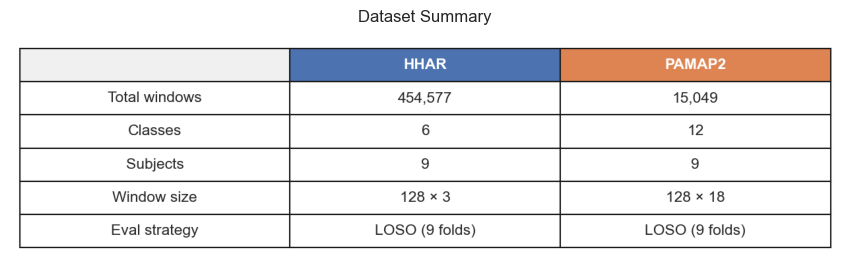

In [2]:
## Dataset Summary Table
img = mpimg.imread(PLOTS / 'eda_dataset_summary_table.png')
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.imshow(img); ax.axis('off')
ax.set_title('Dataset Summary', fontsize=12, pad=8)
plt.tight_layout(); plt.show()


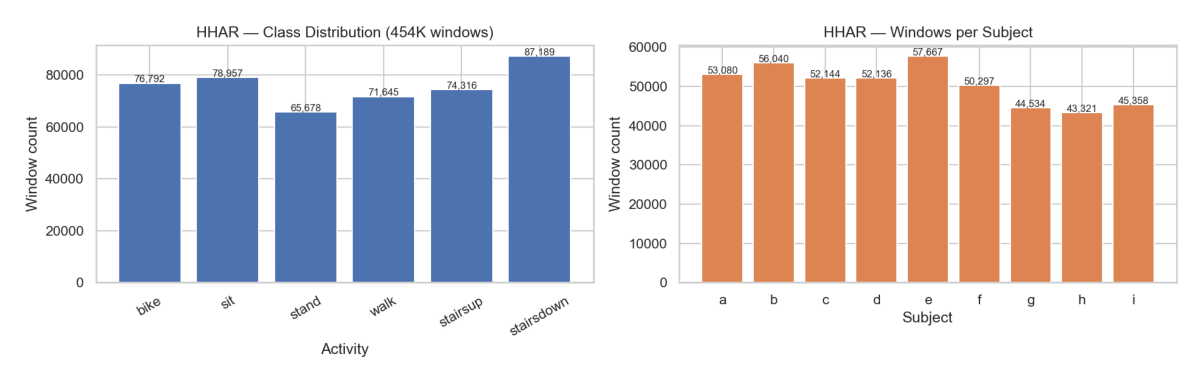

In [3]:
## HHAR — Class & Subject Distribution
img = mpimg.imread(PLOTS / 'eda_hhar_distributions.png')
fig, ax = plt.subplots(figsize=(13, 4))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()


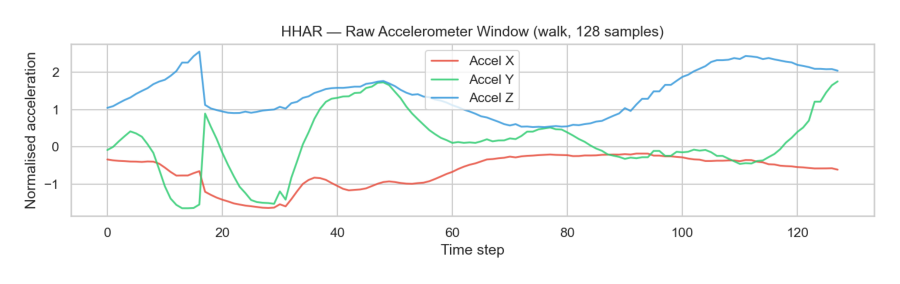

In [4]:
## HHAR — Raw Accelerometer Signal (walk)
img = mpimg.imread(PLOTS / 'eda_hhar_raw_signal.png')
fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()


## 2. PAMAP2 Dataset

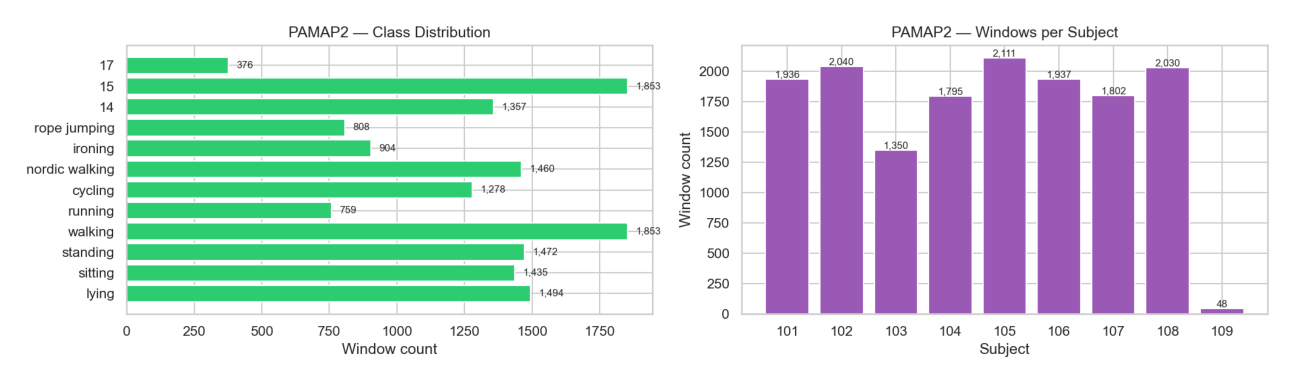

In [5]:
## PAMAP2 — Class & Subject Distribution
img = mpimg.imread(PLOTS / 'eda_pamap2_distributions.png')
fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()


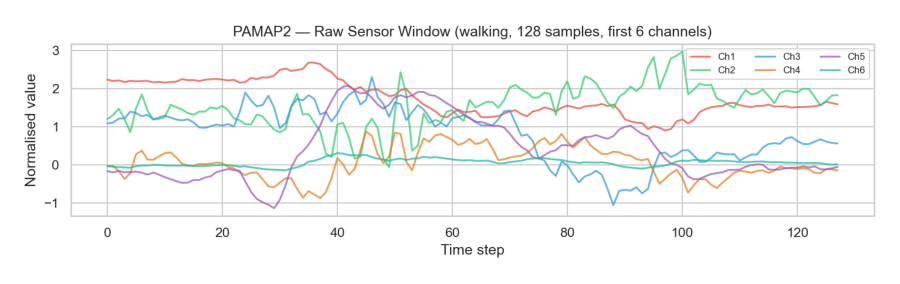

In [6]:
## PAMAP2 — Raw Sensor Signal (walking)
img = mpimg.imread(PLOTS / 'eda_pamap2_raw_signal.png')
fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()


## 3. Processed Data Summary (after preprocessing)

In [7]:
## Processed Data Summary
print(f"{'File':<35} {'Shape':<25} {'dtype'}")
print("-" * 65)
for fname in sorted(PROCESSED.glob('*.npy')):
    arr = np.load(fname)
    print(f"{fname.name:<35} {str(arr.shape):<25} {arr.dtype}")


File                                Shape                     dtype
-----------------------------------------------------------------


hhar_X.npy                          (454577, 128, 3)          float32
hhar_subjects.npy                   (454577,)                 <U1
hhar_y.npy                          (454577,)                 int64
pamap2_X.npy                        (15049, 128, 18)          float32
pamap2_subjects.npy                 (15049,)                  int64
pamap2_y.npy                        (15049,)                  int64


In [8]:
## Key EDA Findings
print("=" * 55)
print("KEY EDA FINDINGS")
print("=" * 55)
print(f"HHAR   total windows : {len(hhar_X):>10,}")
print(f"HHAR   window shape  : {str(hhar_X.shape[1:]):>10}  (128 steps × 3 channels)")
print(f"HHAR   classes       : {len(np.unique(hhar_y)):>10}  (bike/sit/stand/walk/stairsup/stairsdown)")
print(f"HHAR   subjects      : {len(np.unique(hhar_subj)):>10}  (a–i)")
print("-" * 55)
print(f"PAMAP2 total windows : {len(p2_X):>10,}")
print(f"PAMAP2 window shape  : {str(p2_X.shape[1:]):>10}  (128 steps × {p2_X.shape[2]} channels)")
print(f"PAMAP2 classes       : {len(np.unique(p2_y)):>10}  (12 activities)")
print(f"PAMAP2 subjects      : {len(np.unique(p2_subj)):>10}  (101–109)")
print("-" * 55)
print("Preprocessing applied:")
print("  ✓ Resample to 50 Hz (PAMAP2 was 100 Hz)")
print("  ✓ Forward-fill + backward-fill NaNs (PAMAP2)")
print("  ✓ Z-score normalisation per channel")
print("  ✓ Sliding window: 128 samples, 50% overlap")
print("  ✓ LOSO evaluation: 9 folds (one subject held out per fold)")


KEY EDA FINDINGS
HHAR   total windows :    454,577
HHAR   window shape  :   (128, 3)  (128 steps × 3 channels)
HHAR   classes       :          6  (bike/sit/stand/walk/stairsup/stairsdown)
HHAR   subjects      :          9  (a–i)
-------------------------------------------------------
PAMAP2 total windows :     15,049
PAMAP2 window shape  :  (128, 18)  (128 steps × 18 channels)
PAMAP2 classes       :         12  (12 activities)
PAMAP2 subjects      :          9  (101–109)
-------------------------------------------------------
Preprocessing applied:
  ✓ Resample to 50 Hz (PAMAP2 was 100 Hz)
  ✓ Forward-fill + backward-fill NaNs (PAMAP2)
  ✓ Z-score normalisation per channel
  ✓ Sliding window: 128 samples, 50% overlap
  ✓ LOSO evaluation: 9 folds (one subject held out per fold)
